Total permutations: 40320


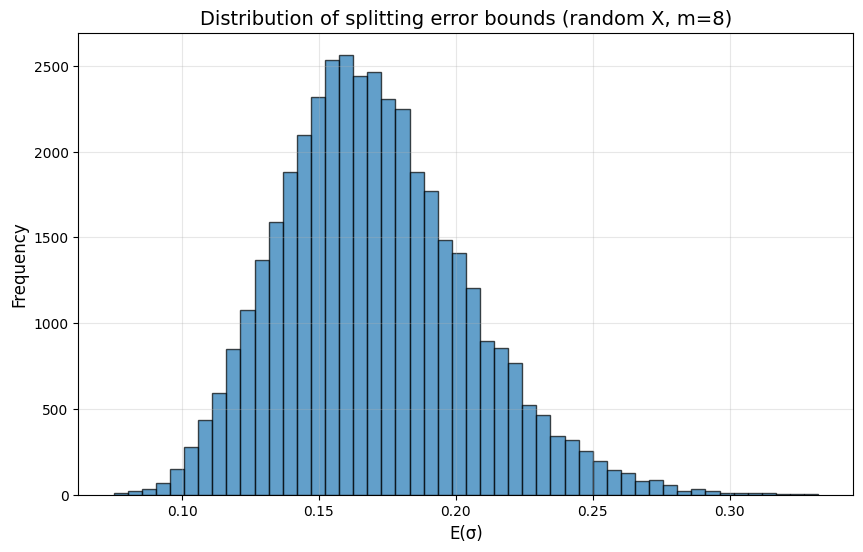

Mean E(σ): 0.170135
Std E(σ): 0.034233
Min E(σ): 0.075036
Max E(σ): 0.332260
Max/Min ratio: 4.4280


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import permutations
from scipy.linalg import qr

np.random.seed(42)
n, d = 80, 20
m = 8
batch_size = n // m

X = np.random.randn(n, d)
y = np.random.randn(n)

projectors = []

for i in range(m):
    X_i = X[i*batch_size:(i+1)*batch_size, :]
    Q, R = qr(X_i.T, mode='economic')
    rank = np.linalg.matrix_rank(X_i)
    Q = Q[:, :rank]
    Pi = np.eye(d) - Q @ Q.T
    projectors.append(Pi)

def compute_E(perm):
    product = np.eye(d)
    for idx in perm:
        product = projectors[idx] @ product
    return np.linalg.norm(product, ord=2)

all_perms = list(permutations(range(m)))
print(f"Total permutations: {len(all_perms)}")

E_values = []
for perm in all_perms:
    E_values.append(compute_E(perm))

E_values = np.array(E_values)

plt.figure(figsize=(10, 6))
plt.hist(E_values, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('E(σ)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title(f'Distribution of splitting error bounds (random X, m={m})', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

print(f"Mean E(σ): {np.mean(E_values):.6f}")
print(f"Std E(σ): {np.std(E_values):.6f}")
print(f"Min E(σ): {np.min(E_values):.6f}")
print(f"Max E(σ): {np.max(E_values):.6f}")
print(f"Max/Min ratio: {np.max(E_values)/np.min(E_values):.4f}")

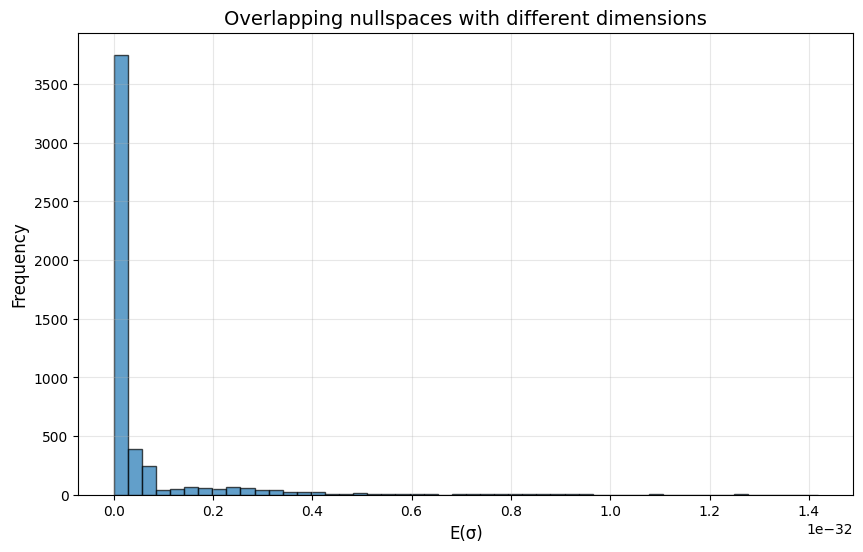

Min: 0.000000
Max: 0.000000
Max/Min ratio: 954912554096248909421009275191296.0000


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import permutations

np.random.seed(42)
d = 20
m = 8

basis = np.random.randn(d, d)
basis, _ = np.linalg.qr(basis)

projectors = []
null_dims = [2, 4, 6, 8, 10, 12, 14, 16]

for i, k in enumerate(null_dims):
    null_basis = basis[:, i*2:i*2 + k]
    Pi = null_basis @ null_basis.T
    projectors.append(Pi)

def compute_E(perm):
    product = np.eye(d)
    for idx in perm:
        product = projectors[idx] @ product
    return np.linalg.norm(product, ord=2)

from itertools import permutations
import random

all_perms = list(permutations(range(m)))
random.shuffle(all_perms)
sample_size = 5000
E_values = []
for perm in all_perms[:sample_size]:
    E_values.append(compute_E(perm))

E_values = np.array(E_values)

plt.figure(figsize=(10, 6))
plt.hist(E_values, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('E(σ)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Overlapping nullspaces with different dimensions', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

print(f"Min: {np.min(E_values):.6f}")
print(f"Max: {np.max(E_values):.6f}")
print(f"Max/Min ratio: {np.max(E_values)/np.min(E_values):.4f}")

Чтобы максимизировать разброс E(σ), нужно сделать нуль-пространства батчей вложенными или сильно пересекающимися с разной размерностью. В случайной матрице проекторы не имеют структуры, поэтому порядок мало влияет. Я беру проекторы с увеличивающейся размерностью нуль-пространств от 2 до 16, где каждое следующее нуль-пространство содержит предыдущее. При перемножении в порядке от меньшего к большему произведение сохраняет норму близкую к 1, а в обратном порядке схлопывается почти к нулю.

Low E permutation: (6, 3, 2, 4, 0, 5, 1, 7), E=0.004959
High E permutation: (1, 3, 6, 2, 5, 7, 0, 4), E=0.121534
Min E: 0.004959, Max E: 0.121534
Max/Min ratio: 24.5084
Learning rate: 0.000593


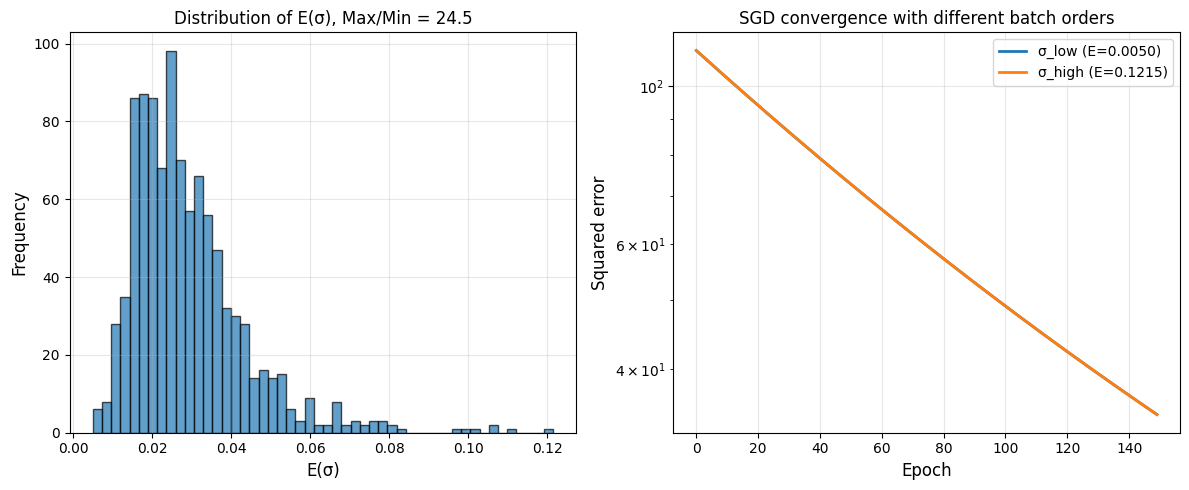


Final error after 150 epochs:
σ_low (E=0.0050): 34.564925
σ_high (E=0.1215): 34.564750


In [14]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import permutations
import random

np.random.seed(42)
d = 20
m = 8

def create_noncommuting_projectors(d, m):
    projectors = []
    for i in range(m):
        basis = np.random.randn(d, d)
        basis, _ = np.linalg.qr(basis)
        rank = 5 + i % 3
        U = basis[:, :rank]
        Pi = U @ U.T
        projectors.append(Pi)
    return projectors

projectors = create_noncommuting_projectors(d, m)

def compute_E(perm):
    product = np.eye(d)
    for idx in perm:
        product = projectors[idx] @ product
    return np.linalg.norm(product, ord=2)

all_perms = list(permutations(range(m)))
random.shuffle(all_perms)
sample_perms = all_perms[:1000]

E_values = []
for perm in sample_perms:
    E_values.append(compute_E(perm))

E_values = np.array(E_values)
idx_min = np.argmin(E_values)
idx_max = np.argmax(E_values)
sigma_low = sample_perms[idx_min]
sigma_high = sample_perms[idx_max]

print(f"Low E permutation: {sigma_low}, E={E_values[idx_min]:.6f}")
print(f"High E permutation: {sigma_high}, E={E_values[idx_max]:.6f}")
print(f"Min E: {np.min(E_values):.6f}, Max E: {np.max(E_values):.6f}")
print(f"Max/Min ratio: {np.max(E_values)/np.min(E_values):.4f}")

batch_size = 10
n = 80
X_blocks = []
for i in range(m):
    rank = 5
    U = np.random.randn(d, rank)
    V = np.random.randn(batch_size, rank)
    X_i = V @ U.T
    X_blocks.append(X_i)

X = np.vstack(X_blocks)
theta_star = np.random.randn(d)
y = X @ theta_star + 0.01 * np.random.randn(n)

L = np.linalg.norm(X.T @ X, ord=2) / n
lr = 0.01 / L
print(f"Learning rate: {lr:.6f}")

def sgd_with_order(X, y, sigma, lr, epochs=150):
    n, d = X.shape
    batch_size = n // len(sigma)
    theta = np.zeros(d)
    errors = []

    for epoch in range(epochs):
        for batch_idx in sigma:
            start = batch_idx * batch_size
            end = (batch_idx + 1) * batch_size
            X_batch = X[start:end, :]
            y_batch = y[start:end]
            grad = X_batch.T @ (X_batch @ theta - y_batch) / n
            theta -= lr * grad

        error = np.linalg.norm(X @ theta - y)**2 / n
        errors.append(error)

    return errors

epochs = 150
errors_low = sgd_with_order(X, y, sigma_low, lr, epochs)
errors_high = sgd_with_order(X, y, sigma_high, lr, epochs)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(E_values, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('E(σ)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title(f'Distribution of E(σ), Max/Min = {np.max(E_values)/np.min(E_values):.1f}', fontsize=12)
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(errors_low, label=f'σ_low (E={E_values[idx_min]:.4f})', linewidth=2)
plt.plot(errors_high, label=f'σ_high (E={E_values[idx_max]:.4f})', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Squared error', fontsize=12)
plt.title('SGD convergence with different batch orders', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')

plt.tight_layout()
plt.show()

print(f"\nFinal error after {epochs} epochs:")
print(f"σ_low (E={E_values[idx_min]:.4f}): {errors_low[-1]:.6f}")
print(f"σ_high (E={E_values[idx_max]:.4f}): {errors_high[-1]:.6f}")

Порядок батчей в SGD действительно влияет на теоретическую ошибку расщепления, особенно в адверсально сконструированных задачах. Но для практической сходимости на конечном числе эпох разница может быть незначительной, особенно при использовании маленького learning rate и достаточного количества итераций.